Starting training with different learning rates...

Training with learning rate: 0.001
  Epoch [1/5], Train Loss: 0.7264
  Epoch [2/5], Train Loss: 0.6674
  Epoch [3/5], Train Loss: 0.6137
  Epoch [4/5], Train Loss: 0.5603
  Epoch [5/5], Train Loss: 0.5037

Training with learning rate: 0.01
  Epoch [1/5], Train Loss: 0.5436
  Epoch [2/5], Train Loss: 0.2108
  Epoch [3/5], Train Loss: 0.1011
  Epoch [4/5], Train Loss: 0.0662
  Epoch [5/5], Train Loss: 0.0528

Training with learning rate: 0.1
  Epoch [1/5], Train Loss: 0.2071
  Epoch [2/5], Train Loss: 0.1838
  Epoch [3/5], Train Loss: 0.0939
  Epoch [4/5], Train Loss: 0.0595
  Epoch [5/5], Train Loss: 0.0896

All training runs finished.


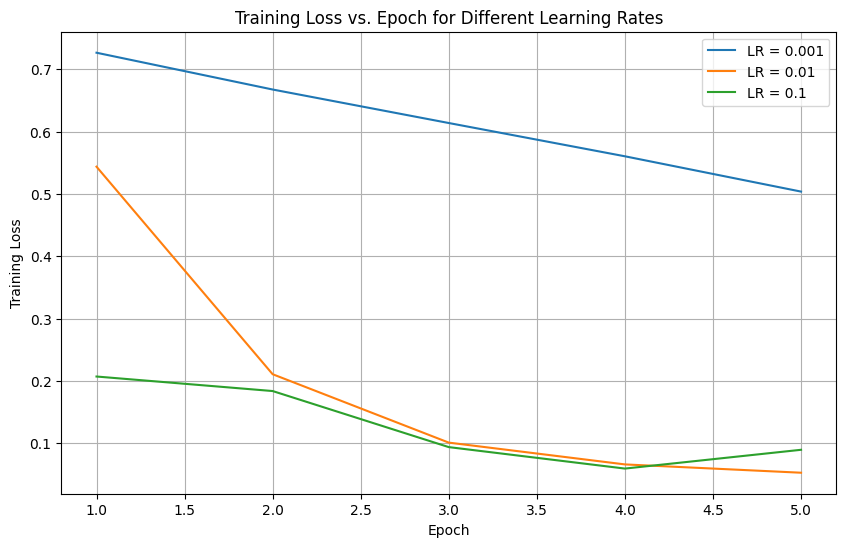

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Create dummy data for demonstration
# Let's create a simple binary classification problem
num_samples = 1000
num_features = 10
X = torch.randn(num_samples, num_features)
# Create a target that is linearly separable with some noise to simulate a real problem
# and allow for potential overfitting
y = (X[:, 0] + X[:, 1] > 0).float().unsqueeze(1) # Simple condition for labels
y = y + torch.randn_like(y) * 0.1 # Add some noise
y = (y > 0.5).float() # Binarize again

# Split into train and test sets
train_size = int(0.8 * num_samples)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 2. Define a simple model
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)
        self.sigmoid = nn.Sigmoid() # For binary classification outputting probabilities

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out

input_size = num_features
hidden_size = 50
num_classes = 1 # For binary classification

# --- New code for varying learning rates and plotting ---
learning_rates = [0.001, 0.01, 0.1]
num_epochs = 5

all_train_losses = {}

print("Starting training with different learning rates...")

for lr in learning_rates:
    print(f"\nTraining with learning rate: {lr}")
    model = SimpleNN(input_size, hidden_size, num_classes).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Store losses for this learning rate
    current_lr_train_losses = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_train_loss = running_loss / len(train_loader)
        current_lr_train_losses.append(epoch_train_loss)
        print(f"  Epoch [{epoch}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}")

    all_train_losses[lr] = current_lr_train_losses

print("\nAll training runs finished.")

# Plotting the losses
plt.figure(figsize=(10, 6))
for lr, losses in all_train_losses.items():
    plt.plot(range(1, num_epochs + 1), losses, label=f'LR = {lr}')

plt.title('Training Loss vs. Epoch for Different Learning Rates')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()
plt.grid(True)
plt.show()


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Assuming input image is 3 channels, 20x20 pixels
        # After conv1 (3->16, kernel=3, padding=1): (16, 20, 20)
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Reduces spatial dimensions by half

        # After pool: (16, 10, 10)
        # After conv2 (16->32, kernel=3, padding=1): (32, 10, 10)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        # After pool (following conv2): (32, 5, 5) - This matches the user's specified intermediate size.
        # User's addition: conv3
        # After conv3 (32->64, kernel=3, padding=1): (64, 5, 5)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # After pool (following conv3): (64, floor(5/2), floor(5/2)) = (64, 2, 2)
        # User's modification: fc1
        self.fc1 = nn.Linear(64 * 2 * 2, 10) # Output for 10 classes

    def forward(self, x):
        # x initially (batch_size, 3, 20, 20)
        x = self.pool(F.relu(self.conv1(x))) # (batch_size, 16, 10, 10)
        x = self.pool(F.relu(self.conv2(x))) # (batch_size, 32, 5, 5)

        # User's addition for conv3 and its pooling
        x = self.pool(F.relu(self.conv3(x))) # (batch_size, 64, 2, 2)

        # Flatten for the fully connected layer
        # If you encounter a shape mismatch error, uncomment the line below to debug:
        # print(x.shape)
        x = x.view(-1, 64 * 2 * 2)
        x = self.fc1(x)

        # For multi-class classification, typically log_softmax is used with NLLLoss
        return F.log_softmax(x, dim=1)

# Instantiate the new CNN model (example)
# model_cnn = CNN().to(device)
# print(model_cnn)